# Recovery Strength Analysis

For each Gibbs component (EoR, Foregrounds, Systematics, Sky, Total Data) this notebook plots:
- **True** (Case I reference)
- **Mean** recovered field for Cases I, II, III
- **Residuals** (True − Mean) for each case

All panels are in delay–fringe-rate (DLFR) space.

In [1]:
import time
_notebook_start = time.time()

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1 import ImageGrid
from astropy import units as u
from tqdm import tqdm
import sys

from uvtools.utils import fourier_freqs
from plotting_functions import plot_waterfalls_from_dlfr
from plotting_codes.functions import data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes

## Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'
parent_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/'
fig_dir    = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'

# ── Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['low_dl_fr_0', 'high_dl_fr_0', 'low_dl_fr_20']

nm_list_arr = [
    [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
    [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
    [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
]

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80
Nfreqs   = 60
Nfgmodes = 10
Niter    = 100000

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

## Derived Parameters

In [3]:
freqs = np.load(parent_dir + 'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6   # MHz
lsts  = np.load(parent_dir + 'res/npy_data/lsts_full.npy')[:Ntimes]

df       = (freqs[1] - freqs[0]) * u.MHz
delays   = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))           # ns

lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                                 # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                   # DLFR(1)

## Styling

In [4]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 28})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

colors   = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ff8fba']
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

## Data Loading — All Cases, All Components

For each case and each Gibbs component (EoR, FG, Sys, Sky, Data) we compute
the **online Welford mean** of the DLFR-transformed sample field.
This avoids storing large `[Niter, Ntimes, Nfreqs]` arrays.

> **Note on the True column:** EoR, FG and Sky truths are identical across cases
> (same signal injection). Systematics and Total Data truths are case-specific;
> Case I is used as the reference True panel for those components.

In [5]:
# ── Output containers ─────────────────────────────────────────────────────────
# True (case-specific for sys/data; reference = Case I for eor/fg/sky)
eor_true_ref  = None   # set from Case I
fg_true_ref   = None
sky_true_ref  = None
sys_true_all  = [None] * 3   # per-case (different modes)
data_true_all = [None] * 3   # per-case (different sys applied)

# Sample means
mean_eor_all  = [None] * 3
mean_fg_all   = [None] * 3
mean_sys_all  = [None] * 3
mean_sky_all  = [None] * 3
mean_data_all = [None] * 3

# Residuals (True_i − Mean_i, using each case's own truth)
res_eor_all   = [None] * 3
res_fg_all    = [None] * 3
res_sys_all   = [None] * 3
res_sky_all   = [None] * 3
res_data_all  = [None] * 3

# ── Main loop ─────────────────────────────────────────────────────────────────
for case_i, run_ver in enumerate(run_version_arr):
    print(f'\n=== Case {case_i + 1} / 3  ({run_ver}) ===')
    op_i = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[case_i])

    # ── Load samples and true fields ──────────────────────────────────────────
    eor_true_i  = np.load(result_dir + run_ver + '/eor_true.npy')
    fg_true_i   = np.load(result_dir + run_ver + '/fg_true.npy')
    data_true_i = np.load(result_dir + run_ver + '/data_true.npy')
    fgmodes_i   = np.load(result_dir + run_ver + '/fgmodes.npy')
    fg_amps_i   = np.load(result_dir + run_ver + '/fg-amps.npy')
    eor_gcr_i   = np.load(result_dir + run_ver + '/gcr-eor.npy')
    b_sys_i     = np.load(result_dir + run_ver + '/b-sys.npy')

    delta_g_true_i = (op_i @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
    sky_true_i     = eor_true_i + fg_true_i

    sys_true_all[case_i]  = 1+delta_g_true_i
    data_true_all[case_i] = data_true_i

    # ── Welford online mean for all 5 components ──────────────────────────────
    n_s     = 0
    eor_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    fg_mu   = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sys_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sky_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    data_mu = np.zeros((Ntimes, Nfreqs), dtype='complex')

    print('  Processing samples...')
    for j in tqdm(range(Niter)):
        fg_vis_j  = (fgmodes_i @ fg_amps_i[j].T).T
        dg_j      = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        sky_j     = eor_gcr_i[j] + fg_vis_j
        data_j    = (1. + dg_j) * sky_j


        # Running mean update  μ_n = μ_{n-1} + (x - μ_{n-1}) / n
        n_s    += 1
        eor_mu  += (eor_gcr_i[j]  - eor_mu)  / n_s
        fg_mu   += (fg_vis_j   - fg_mu)   / n_s
        sys_mu  += ((1+dg_j)  - sys_mu)  / n_s
        sky_mu  += (sky_j  - sky_mu)  / n_s
        data_mu += (data_j - data_mu) / n_s

    mean_eor_all[case_i]  = eor_mu
    mean_fg_all[case_i]   = fg_mu
    mean_sys_all[case_i]  = sys_mu
    mean_sky_all[case_i]  = sky_mu
    mean_data_all[case_i] = data_mu

    # Residuals: each case compared against its own truth
    res_eor_all[case_i]   = eor_true_i  - eor_mu
    res_fg_all[case_i]    = fg_true_i   - fg_mu
    res_sys_all[case_i]   = (1+delta_g_true_i)  - sys_mu
    res_sky_all[case_i]   = sky_true_i  - sky_mu
    res_data_all[case_i]  = data_true_i - data_mu

print('\nAll cases done.')


=== Case 1 / 3  (low_dl_fr_0) ===
3 0
4 0
5 0
6 0
  Processing samples...


100%|██████████| 100000/100000 [00:45<00:00, 2197.56it/s]



=== Case 2 / 3  (high_dl_fr_0) ===
10 0
11 0
12 0
13 0
  Processing samples...


100%|██████████| 100000/100000 [00:47<00:00, 2114.39it/s]



=== Case 3 / 3  (low_dl_fr_20) ===
3 20
4 20
5 20
6 20
  Processing samples...


100%|██████████| 100000/100000 [00:46<00:00, 2134.25it/s]


All cases done.


## Recovery Strength Figure

**Layout:** 5 rows × 7 columns.  
- Left block (cols 0–3): True + Mean I/II/III — log-scale pink colourmap, one shared colourbar.  
- Right block (cols 4–6): Residuals I/II/III — diverging colourmap, one shared colourbar.

Each row is an independent `ImageGrid` pair placed inside a `GridSpecFromSubplotSpec`.

ValueError: Array shape () does not match (len(lsts), len(freqs))=(80, 60) or (len(freqs), len(lsts))=(60, 80).

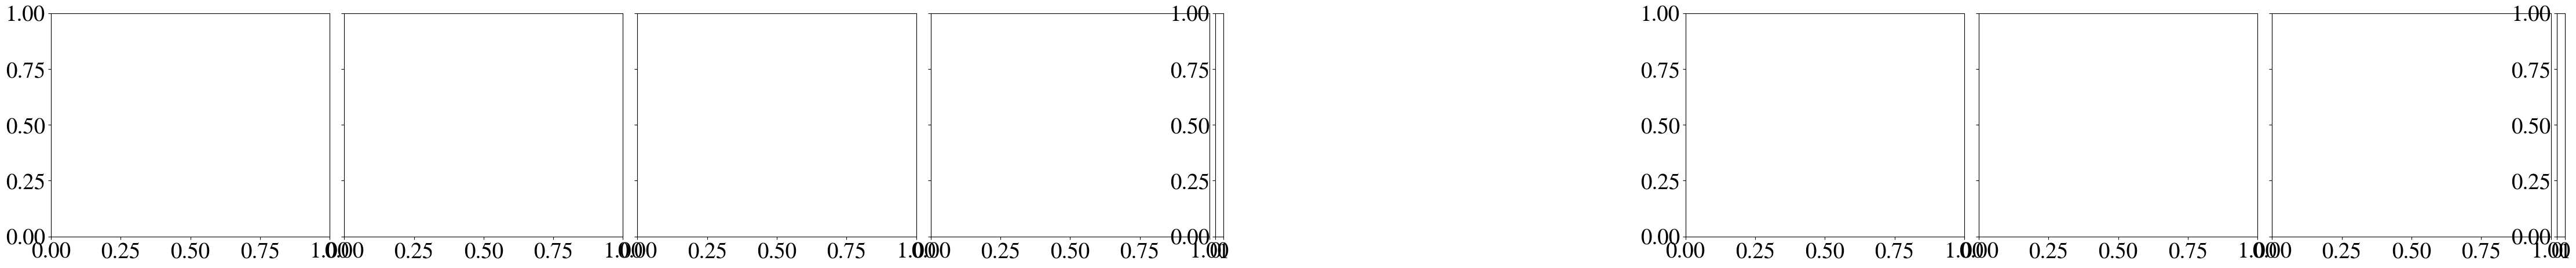

In [8]:
# ── Per-row plot configuration ────────────────────────────────────────────────
# vmin_r / vmax_r for residuals may need tuning per dataset
row_configs = [
    dict(
        label      = 'EoR',
        true       = eor_true_ref,
        means      = mean_eor_all,
        res        = res_eor_all,
        vmin_r=-0.5,  vmax_r=0.5,
    ),
    dict(
        label      = 'Foregrounds',
        true       = fg_true_ref,
        means      = mean_fg_all,
        res        = res_fg_all,
        vmin_r=-1.0,  vmax_r=1.0,
    ),
    dict(
        label      = r'Systematics' + '\n' + r'($\delta g$)',
        true       = sys_true_all[0],
        means      = mean_sys_all,
        res        = res_sys_all,
        vmin_r=-0.02, vmax_r=0.02,
    ),
    dict(
        label      = 'Sky',
        true       = sky_true_ref,
        means      = mean_sky_all,
        res        = res_sky_all,
        vmin_r=-1.0,  vmax_r=1.0,
    ),
    dict(
        label      = 'Total Data',
        true       = data_true_all[0],
        means      = mean_data_all,
        res        = res_data_all,
        vmin_r=-1.0,  vmax_r=1.0,
    ),
]

case_lbl   = ['Case I', 'Case II', 'Case III']
col_titles = ['True',
              r'$\mu$ Case I', r'$\mu$ Case II', r'$\mu$ Case III',
              'Res. Case I', 'Res. Case II', 'Res. Case III']

# ------------------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------------------

def prepare_for_imshow(arr, freqs, lsts):
    """
    Ensure array shape matches (len(lsts), len(freqs)) for imshow with
    x = frequency and y = LST.
    """
    arr = np.asarray(arr)
    if arr.shape == (len(lsts), len(freqs)):
        return arr
    elif arr.shape == (len(freqs), len(lsts)):
        return arr.T
    else:
        raise ValueError(
            f"Array shape {arr.shape} does not match "
            f"(len(lsts), len(freqs))={(len(lsts), len(freqs))} "
            f"or (len(freqs), len(lsts))={(len(freqs), len(lsts))}."
        )

def log_image(arr, dynamic_range=5):
    """
    Replicate the old 'mode=log, dynamic_range=5' behaviour approximately
    by plotting log10(abs(arr)) with vmin = vmax - dynamic_range.
    """
    img = np.log10(np.abs(arr))
    vmax = np.nanmax(img)
    vmin = vmax - dynamic_range
    return img, vmin, vmax

extent = [freqs.min(), freqs.max(), lsts.min(), lsts.max()]

# ── Figure and outer GridSpec (one row-band per component) ────────────────────
fig = plt.figure(figsize=(56, 35))
outer_gs = GridSpec(5, 1, figure=fig, hspace=0.5)

for row, cfg in enumerate(row_configs):

    # Sub-spec: left block (4 panels) | right block (3 panels)
    inner_gs = GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row],
        width_ratios=[4, 3], wspace=0.45,
    )

    # Left: True + 3 means, pink log-scale, single colourbar
    grid_lft = ImageGrid(
        fig, inner_gs[0],
        nrows_ncols=(1, 4),
        axes_pad=0.25, share_all=True,
        cbar_location='right', cbar_mode='single',
        cbar_size='3%', cbar_pad=0.1, aspect=False,
    )

    # Right: 3 residuals, diverging colourmap, single colourbar
    grid_rgt = ImageGrid(
        fig, inner_gs[1],
        nrows_ncols=(1, 3),
        axes_pad=0.25, share_all=True,
        cbar_location='right', cbar_mode='single',
        cbar_size='3%', cbar_pad=0.1, aspect=False,
    )

    # ── True panel ────────────────────────────────────────────────────────────
    true_img = prepare_for_imshow(cfg['true'], freqs, lsts)
    true_plot, vmin_l, vmax_l = log_image(true_img, dynamic_range=5)

    im_l = grid_lft[0].imshow(
        true_plot,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap=paper_map_pink,
        vmin=vmin_l,
        vmax=vmax_l,
        interpolation='nearest',
    )
    grid_lft[0].text(
        0.95, 0.07, 'True', bbox=bbox,
        transform=grid_lft[0].transAxes, ha='right'
    )

    # ── Mean panels (Cases I–III) ─────────────────────────────────────────────
    for ci in range(3):
        mean_img = prepare_for_imshow(cfg['means'][ci], freqs, lsts)
        mean_plot, _, _ = log_image(mean_img, dynamic_range=5)

        im_l = grid_lft[ci + 1].imshow(
            mean_plot,
            origin='lower',
            aspect='auto',
            extent=extent,
            cmap=paper_map_pink,
            vmin=vmin_l,
            vmax=vmax_l,
            interpolation='nearest',
        )
        grid_lft[ci + 1].text(
            0.95, 0.07, r'$\mu$ ' + case_lbl[ci], bbox=bbox,
            transform=grid_lft[ci + 1].transAxes, ha='right'
        )

    # ── Residual panels (Cases I–III) ─────────────────────────────────────────
    for ci in range(3):
        res_img = prepare_for_imshow(cfg['res'][ci], freqs, lsts)

        im_r = grid_rgt[ci].imshow(
            res_img,
            origin='lower',
            aspect='auto',
            extent=extent,
            cmap=paper_map,
            vmin=cfg['vmin_r'],
            vmax=cfg['vmax_r'],
            interpolation='nearest',
        )
        grid_rgt[ci].text(
            0.95, 0.07, 'Res. ' + case_lbl[ci], bbox=bbox_res,
            transform=grid_rgt[ci].transAxes, ha='right'
        )

    # ── Shared colourbars ─────────────────────────────────────────────────────
    grid_lft.cbar_axes[0].colorbar(im_l, label=r'$\log_{10}|V|$')
    grid_rgt.cbar_axes[0].colorbar(im_r, label='Residuals (Absolute Values)')

    # ── Y-axis row label on leftmost panel ────────────────────────────────────
    grid_lft[0].set_ylabel(cfg['label'], fontsize=30, labelpad=10)

    # ── Axes labels / crosshairs on every panel ───────────────────────────────
    for ax in list(grid_lft) + list(grid_rgt):
        ax.axvline(0, color=colors[0], linestyle='--', linewidth=1)
        ax.axhline(0, color=colors[0], linestyle='--', linewidth=1)
        ax.set_xlabel('Frequency [MHz]', fontsize=24)

    # Set LST label only on first panel of each row
    grid_lft[0].set_ylabel(cfg['label'] + '\nLST [hr]', fontsize=30, labelpad=10)

    # ── Column headers on top row only ────────────────────────────────────────
    if row == 0:
        for ax, hdr in zip(list(grid_lft) + list(grid_rgt), col_titles):
            ax.set_title(hdr, fontsize=28, pad=12)

# plt.savefig(fig_dir + '/recovery_strength.pdf', bbox_inches='tight', dpi=300)
print('Saved.')

In [ ]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f'Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s')